# SIFT Part 1: Scale-Space and Difference of Gaussians

## The Problem: Why Do We Need Scale Invariance?

Imagine you take a photo of a Sudoku puzzle from 1 meter away, then another from 2 meters away. The same corner of a cell might be:
- 20x20 pixels in the close image
- 10x10 pixels in the far image

A simple corner detector would find different "interesting points" at different scales. **We need a way to find the SAME points regardless of image scale.**

## Key Insight: Look at Multiple Scales Simultaneously

SIFT's solution: Build a **scale-space** - a stack of increasingly blurred versions of the image. Then find points that are "interesting" across multiple scales.

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# For loading test images
import cv2

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Gaussian Blur: The Foundation

### What is Gaussian Blur?

Gaussian blur smooths an image by averaging each pixel with its neighbors, weighted by a bell curve (Gaussian function).

$$G(x, y, \sigma) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}$$

Where:
- $(x, y)$ = distance from center pixel
- $\sigma$ = **scale parameter** (controls blur amount)

### Why Gaussian?

1. **Simulates distance**: Blurring mimics what happens when you move away from an object
2. **Mathematically nice**: Gaussian is the ONLY filter that doesn't introduce new features when blurring
3. **Separable**: Can apply 1D blur horizontally then vertically (faster)

In [68]:
def gaussian_kernel_1d(sigma, size=None):
    """
    Create a 1D Gaussian kernel.
    
    Args:
        sigma: Standard deviation (controls blur amount)
        size: Kernel size (if None, automatically calculated)
    
    Returns:
        1D numpy array representing the Gaussian kernel
    """
    # Rule of thumb: kernel size should be 6*sigma to capture 99.7% of the distribution
    if size is None:
        size = int(np.ceil(6 * sigma))
        if size % 2 == 0:
            size += 1  # Make it odd for symmetric kernel
    
    # Create coordinate array centered at 0
    x = np.arange(size) - size // 2
    
    # Apply Gaussian formula
    kernel = np.exp(-x**2 / (2 * sigma**2))
    
    # Normalize so sum = 1 (preserves image brightness)
    kernel = kernel / kernel.sum()
    
    return kernel


def gaussian_blur(image, sigma):
    """
    Apply Gaussian blur using separable convolution.
    
    Instead of 2D convolution (slow), we apply 1D blur twice:
    1. Horizontally across rows
    2. Vertically across columns
    
    This is O(n*k) instead of O(n*k^2) where k is kernel size.
    """
    kernel = gaussian_kernel_1d(sigma)
    
    # Pad image to handle borders
    pad = len(kernel) // 2
    padded = np.pad(image, pad, mode='reflect')
    
    # Horizontal pass
    temp = np.zeros_like(padded, dtype=np.float64)
    for i in range(len(kernel)):
        temp[:, pad:-pad] += kernel[i] * padded[:, i:i+image.shape[1]]
    
    # Vertical pass
    result = np.zeros_like(image, dtype=np.float64)
    for i in range(len(kernel)):
        result += kernel[i] * temp[i:i+image.shape[0], pad:-pad]
    
    return result

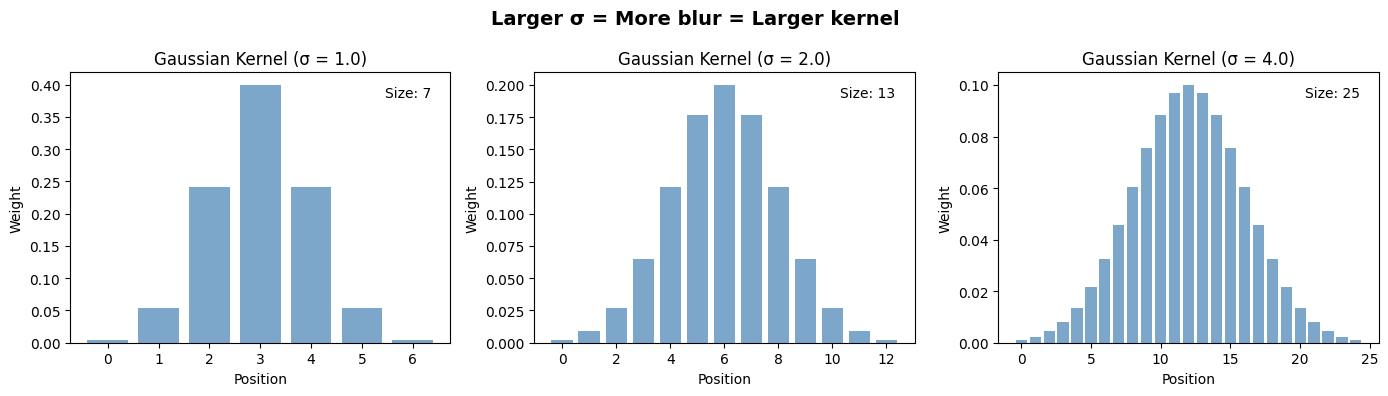

In [69]:
# Visualize Gaussian kernels at different scales
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sigmas = [1.0, 2.0, 4.0]
for ax, sigma in zip(axes, sigmas):
    kernel = gaussian_kernel_1d(sigma)
    ax.bar(range(len(kernel)), kernel, color='steelblue', alpha=0.7)
    ax.set_title(f'Gaussian Kernel (σ = {sigma})', fontsize=12)
    ax.set_xlabel('Position')
    ax.set_ylabel('Weight')
    ax.text(0.95, 0.95, f'Size: {len(kernel)}', transform=ax.transAxes, 
            ha='right', va='top', fontsize=10)

plt.suptitle('Larger σ = More blur = Larger kernel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Scale-Space: A Stack of Blurred Images

### The Concept

Scale-space $L(x, y, \sigma)$ is a 3D representation where:
- $(x, y)$ = spatial coordinates
- $\sigma$ = scale (blur level)

$$L(x, y, \sigma) = G(x, y, \sigma) * I(x, y)$$

Where $*$ denotes convolution and $I$ is the original image.

### SIFT's Scale-Space Structure

SIFT organizes scale-space into **octaves** and **scales**:

```
Octave 0: [σ, k*σ, k²*σ, k³*σ, k⁴*σ, k⁵*σ]  (original resolution)
Octave 1: [σ, k*σ, k²*σ, k³*σ, k⁴*σ, k⁵*σ]  (half resolution)
Octave 2: [σ, k*σ, k²*σ, k³*σ, k⁴*σ, k⁵*σ]  (quarter resolution)
...
```

Where $k = 2^{1/s}$ and $s$ = number of scales per octave (typically 3).

In [70]:
def build_gaussian_pyramid(image, num_octaves=4, num_scales=5, sigma_base=1.6):
    """
    Build a Gaussian scale-space pyramid.
    
    Args:
        image: Input grayscale image (normalized to 0-1)
        num_octaves: Number of octaves (resolution levels)
        num_scales: Number of blur levels per octave (s+3 in Lowe's paper)
        sigma_base: Base sigma value
    
    Returns:
        List of octaves, each octave is a list of blurred images
    """
    # k = 2^(1/s) where s = num_scales - 3 (we need s+3 images to get s DoG extrema)
    s = num_scales - 3
    k = 2 ** (1 / s)
    
    pyramid = []
    sigmas_per_octave = []  # Track sigma values for reference
    
    # Compute sigma values for one octave
    sigma_values = [sigma_base * (k ** i) for i in range(num_scales)]
    
    current_image = image.astype(np.float64)
    
    for octave in range(num_octaves):
        octave_images = []
        octave_sigmas = []
        
        for scale_idx, sigma in enumerate(sigma_values):
            if scale_idx == 0 and octave == 0:
                # First image: blur original
                blurred = gaussian_blur(current_image, sigma)
            elif scale_idx == 0:
                # Start of new octave: use downsampled version
                blurred = gaussian_blur(current_image, sigma)
            else:
                # Incremental blur: blur from previous scale
                # sigma_diff = sqrt(sigma_new^2 - sigma_prev^2)
                sigma_prev = sigma_values[scale_idx - 1]
                sigma_diff = np.sqrt(sigma**2 - sigma_prev**2)
                blurred = gaussian_blur(octave_images[-1], sigma_diff)
            
            octave_images.append(blurred)
            # Effective sigma in original image coordinates
            octave_sigmas.append(sigma * (2 ** octave))
        
        pyramid.append(octave_images)
        sigmas_per_octave.append(octave_sigmas)
        
        # Downsample for next octave (take every other pixel)
        # Use the image at scale index s (where sigma = 2*sigma_base)
        if octave < num_octaves - 1:
            current_image = octave_images[s][::2, ::2]
    
    return pyramid, sigmas_per_octave

Loaded image from: ../data/_18_7253552.jpeg
Image shape: (400, 400)


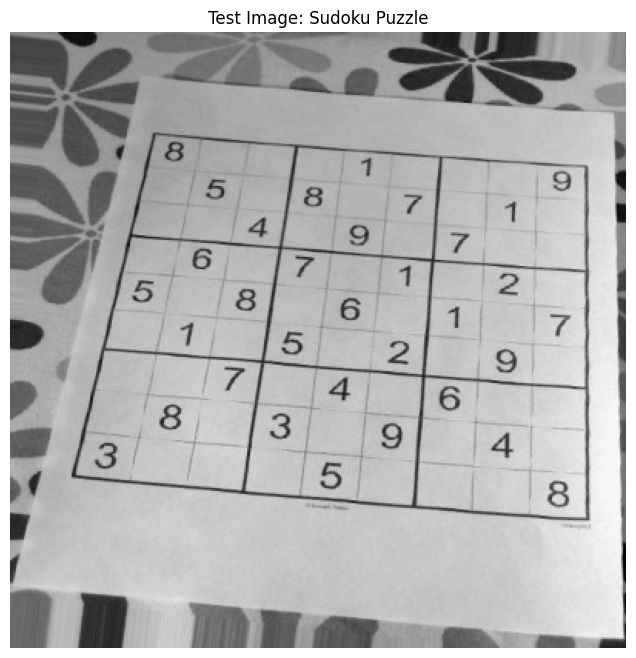

In [71]:
# Load the test image from the data folder
data_path = Path('../data')
image_path = data_path / '_18_7253552.jpeg'

if image_path.exists():
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    print(f"Loaded image from: {image_path}")
else:
    raise FileNotFoundError(f"Image not found at {image_path}. Please add a JPEG to the data folder.")

# Resize for faster processing (optional - comment out to use full resolution)
img = cv2.resize(img, (400, 400))

# Normalize to 0-1
img_normalized = img.astype(np.float64) / 255.0

print(f"Image shape: {img.shape}")
plt.figure(figsize=(8, 8))
plt.imshow(img, cmap='gray')
plt.title('Test Image: Sudoku Puzzle')
plt.axis('off')
plt.show()

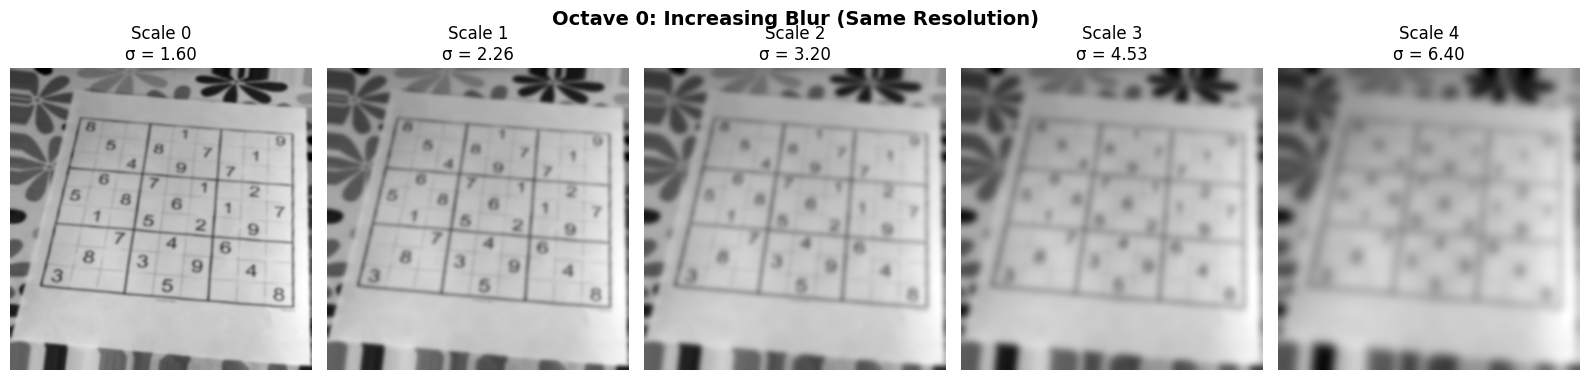

In [ ]:
# Build the Gaussian pyramid-
pyramid, sigmas = build_gaussian_pyramid(img_normalized, num_octaves=4, num_scales=5)

# Visualize first octave
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for i, (ax, scale_img) in enumerate(zip(axes, pyramid[0])):
    ax.imshow(scale_img, cmap='gray')
    ax.set_title(f'Scale {i}\nσ = {sigmas[0][i]:.2f}')
    ax.axis('off')

plt.suptitle('Octave 0: Increasing Blur (Same Resolution)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

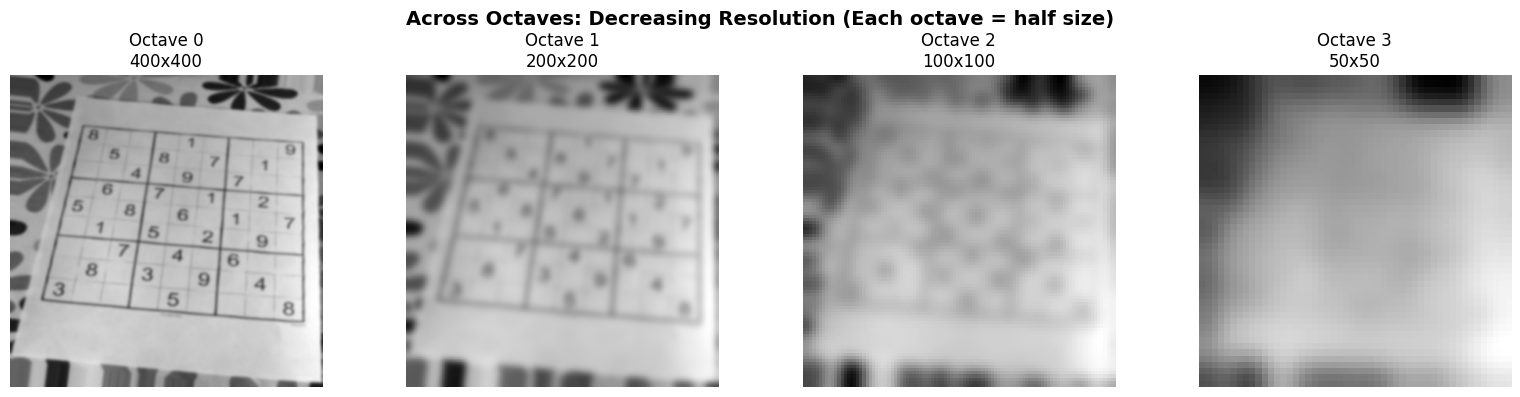

In [73]:
# Visualize across octaves (first scale of each)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for octave_idx, ax in enumerate(axes):
    octave_img = pyramid[octave_idx][0]
    ax.imshow(octave_img, cmap='gray')
    ax.set_title(f'Octave {octave_idx}\n{octave_img.shape[0]}x{octave_img.shape[1]}')
    ax.axis('off')

plt.suptitle('Across Octaves: Decreasing Resolution (Each octave = half size)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Difference of Gaussians (DoG): Finding "Interesting" Scales

### The Key Insight

We want to find **blob-like structures** (corners, spots) that exist at specific scales. The Difference of Gaussians approximates the **Laplacian of Gaussian (LoG)** - a mathematical operator that detects blobs.

$$DoG(x, y, \sigma) = L(x, y, k\sigma) - L(x, y, \sigma)$$

### Why DoG Works

1. **Subtracting two blurs** highlights features at a specific scale
2. Features **larger** than both scales: blurred out in both → canceled
3. Features **smaller** than both scales: present in both → canceled
4. Features **between** the two scales: present in one, blurred in other → **detected!**

### Visual Intuition

```
Light blur - Heavy blur = Features at that scale
     ┌───┐      ┌───┐      ┌───┐
     │ · │  -   │   │  =   │ · │  ← Blob detected!
     └───┘      └───┘      └───┘
```

In [74]:
def build_dog_pyramid(gaussian_pyramid):
    """
    Build Difference of Gaussians pyramid from Gaussian pyramid.
    
    Each DoG image = G(σ_i+1) - G(σ_i)
    
    If Gaussian pyramid has N images per octave,
    DoG pyramid has N-1 images per octave.
    """
    dog_pyramid = []
    
    for octave_images in gaussian_pyramid:
        dog_octave = []
        
        for i in range(len(octave_images) - 1):
            # Subtract adjacent Gaussian images
            dog = octave_images[i + 1] - octave_images[i]
            dog_octave.append(dog)
        
        dog_pyramid.append(dog_octave)
    
    return dog_pyramid

In [75]:
# Build DoG pyramid
dog_pyramid = build_dog_pyramid(pyramid)

print(f"Gaussian pyramid: {len(pyramid)} octaves, {len(pyramid[0])} scales each")
print(f"DoG pyramid: {len(dog_pyramid)} octaves, {len(dog_pyramid[0])} DoG images each")

Gaussian pyramid: 4 octaves, 5 scales each
DoG pyramid: 4 octaves, 4 DoG images each


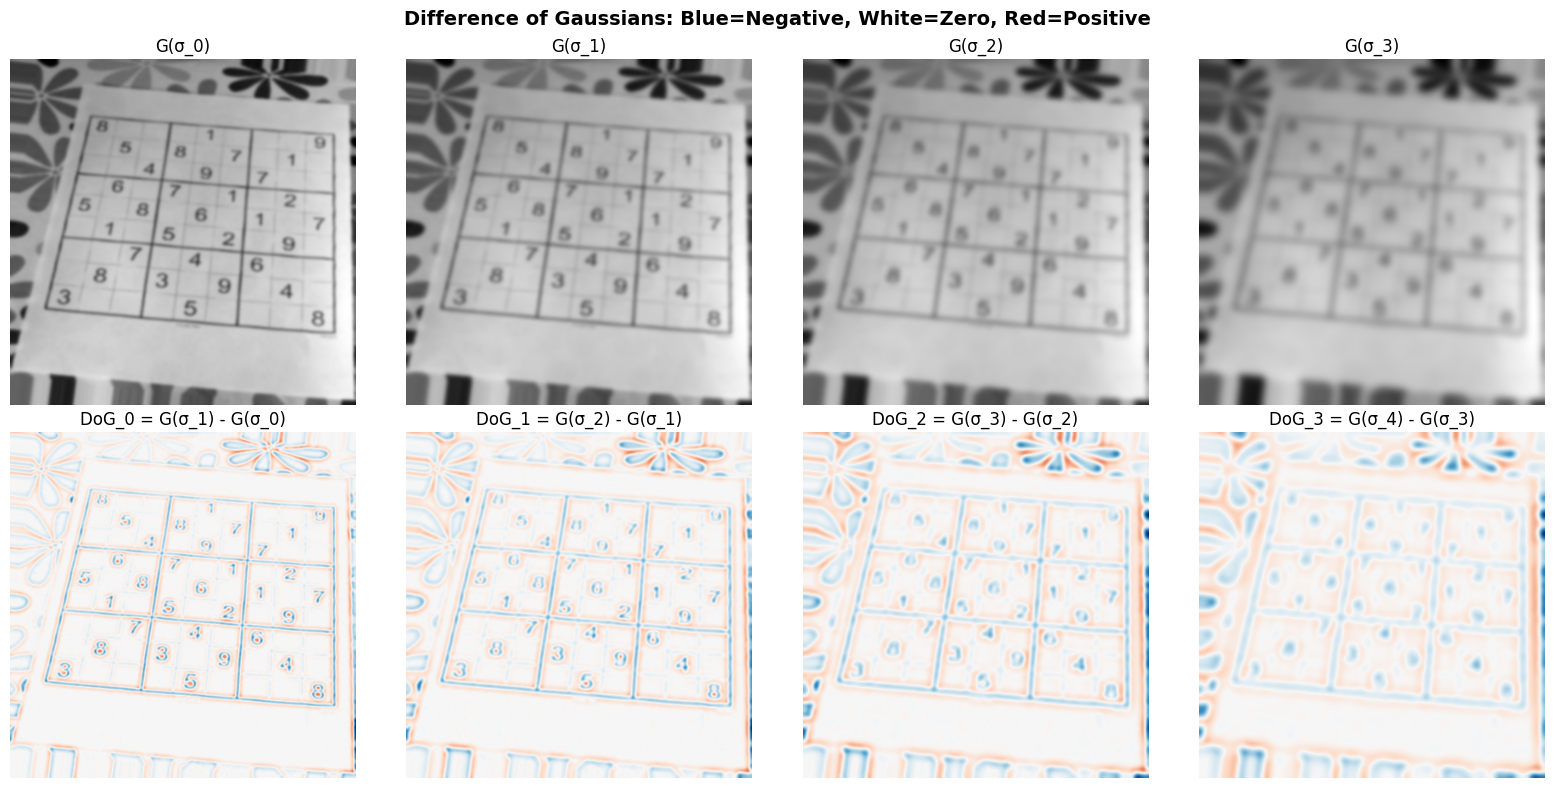

In [76]:
# Visualize DoG images for first octave
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Top row: Gaussian images being subtracted
for i in range(4):
    axes[0, i].imshow(pyramid[0][i], cmap='gray')
    axes[0, i].set_title(f'G(σ_{i})')
    axes[0, i].axis('off')

# Bottom row: DoG results
for i in range(4):
    # Normalize DoG for visualization (it has positive and negative values)
    dog_img = dog_pyramid[0][i]
    vmax = np.abs(dog_img).max()
    axes[1, i].imshow(dog_img, cmap='RdBu', vmin=-vmax, vmax=vmax)
    axes[1, i].set_title(f'DoG_{i} = G(σ_{i+1}) - G(σ_{i})')
    axes[1, i].axis('off')

plt.suptitle('Difference of Gaussians: Blue=Negative, White=Zero, Red=Positive', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Finding Extrema: The Interest Points

### The Detection Rule

A pixel is a potential keypoint if it is a **local extremum** (maximum or minimum) compared to its **26 neighbors**:

```
         Scale σ-1          Scale σ           Scale σ+1
         ┌───┬───┬───┐     ┌───┬───┬───┐     ┌───┬───┬───┐
         │ · │ · │ · │     │ · │ · │ · │     │ · │ · │ · │
         ├───┼───┼───┤     ├───┼───┼───┤     ├───┼───┼───┤
         │ · │ · │ · │     │ · │ X │ · │     │ · │ · │ · │
         ├───┼───┼───┤     ├───┼───┼───┤     ├───┼───┼───┤
         │ · │ · │ · │     │ · │ · │ · │     │ · │ · │ · │
         └───┴───┴───┘     └───┴───┴───┘     └───┴───┴───┘
              9 neighbors  +  8 neighbors  +     9 neighbors = 26 total
```

Point X is a keypoint if it's larger (or smaller) than ALL 26 neighbors.

### Why This Works

- Extrema in **space** (x, y): point is distinctive in its local neighborhood
- Extrema in **scale** (σ): point has a characteristic scale where it's most prominent
- This is what makes SIFT **scale-invariant**!

In [77]:
def find_dog_extrema(dog_pyramid, threshold=0.03):
    """
    Find local extrema in the DoG pyramid.
    
    Args:
        dog_pyramid: List of octaves, each with DoG images
        threshold: Minimum absolute value to consider (removes weak responses)
    
    Returns:
        List of keypoints: (octave, scale, y, x, is_maximum)
    """
    keypoints = []
    
    for octave_idx, dog_octave in enumerate(dog_pyramid):
        # Need at least 3 DoG images to find extrema (compare with scale above and below)
        if len(dog_octave) < 3:
            continue
        
        # Check scales 1 to n-2 (need neighbors above and below)
        for scale_idx in range(1, len(dog_octave) - 1):
            current = dog_octave[scale_idx]
            below = dog_octave[scale_idx - 1]
            above = dog_octave[scale_idx + 1]
            
            height, width = current.shape
            
            # Check each pixel (excluding 1-pixel border)
            for y in range(1, height - 1):
                for x in range(1, width - 1):
                    val = current[y, x]
                    
                    # Skip weak responses
                    if abs(val) < threshold:
                        continue
                    
                    # Get all 26 neighbors
                    neighbors = []
                    
                    # 9 from scale below
                    neighbors.extend(below[y-1:y+2, x-1:x+2].flatten())
                    
                    # 8 from current scale (excluding center)
                    for dy in [-1, 0, 1]:
                        for dx in [-1, 0, 1]:
                            if dy != 0 or dx != 0:
                                neighbors.append(current[y + dy, x + dx])
                    
                    # 9 from scale above
                    neighbors.extend(above[y-1:y+2, x-1:x+2].flatten())
                    
                    # Check if extremum
                    is_max = val > max(neighbors)
                    is_min = val < min(neighbors)
                    
                    if is_max or is_min:
                        keypoints.append({
                            'octave': octave_idx,
                            'scale': scale_idx,
                            'y': y,
                            'x': x,
                            'response': val,
                            'is_maximum': is_max
                        })
    
    return keypoints

In [78]:
# Find extrema
keypoints = find_dog_extrema(dog_pyramid, threshold=0.03)

print(f"Found {len(keypoints)} potential keypoints")

# Count by octave
for octave in range(len(dog_pyramid)):
    count = sum(1 for kp in keypoints if kp['octave'] == octave)
    print(f"  Octave {octave}: {count} keypoints")

Found 142 potential keypoints
  Octave 0: 108 keypoints
  Octave 1: 33 keypoints
  Octave 2: 1 keypoints
  Octave 3: 0 keypoints


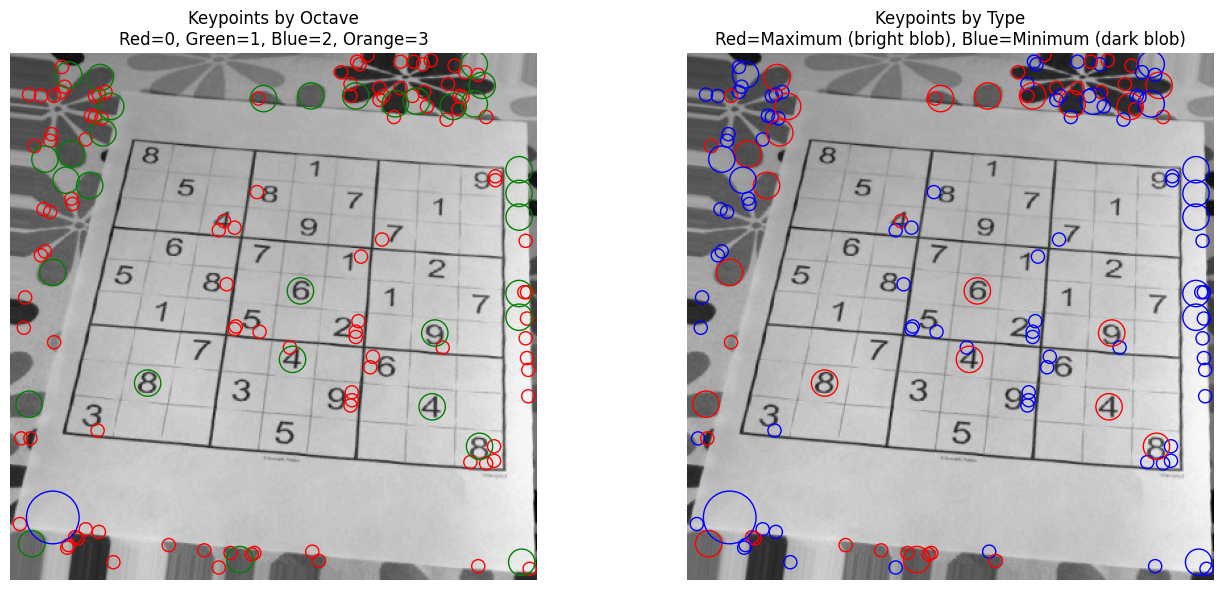

In [79]:
def convert_keypoint_to_image_coords(kp):
    """
    Convert keypoint from octave coordinates to original image coordinates.
    
    Each octave is half the resolution, so multiply by 2^octave.
    """
    scale_factor = 2 ** kp['octave']
    return {
        'x': kp['x'] * scale_factor,
        'y': kp['y'] * scale_factor,
        'octave': kp['octave'],
        'scale': kp['scale'],
        'response': kp['response'],
        'is_maximum': kp['is_maximum']
    }


# Visualize keypoints on original image
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: show by octave (color coded)
axes[0].imshow(img, cmap='gray')
colors = ['red', 'green', 'blue', 'orange']

for kp in keypoints:
    img_kp = convert_keypoint_to_image_coords(kp)
    color = colors[kp['octave']]
    size = 5 * (2 ** kp['octave'])  # Larger circles for higher octaves
    circle = plt.Circle((img_kp['x'], img_kp['y']), size, 
                         fill=False, color=color, linewidth=1)
    axes[0].add_patch(circle)

axes[0].set_title('Keypoints by Octave\nRed=0, Green=1, Blue=2, Orange=3')
axes[0].axis('off')

# Right: show max vs min
axes[1].imshow(img, cmap='gray')

for kp in keypoints:
    img_kp = convert_keypoint_to_image_coords(kp)
    color = 'red' if kp['is_maximum'] else 'blue'
    size = 5 * (2 ** kp['octave'])
    circle = plt.Circle((img_kp['x'], img_kp['y']), size,
                         fill=False, color=color, linewidth=1)
    axes[1].add_patch(circle)

axes[1].set_title('Keypoints by Type\nRed=Maximum (bright blob), Blue=Minimum (dark blob)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 5. Summary: What We've Learned

### Scale Invariance Achieved!

1. **Gaussian Pyramid**: Blur image at multiple scales using Gaussian filters
2. **Difference of Gaussians**: Subtract adjacent scales to find scale-specific features
3. **Extrema Detection**: Find points that are maxima/minima across BOTH space AND scale

### Why This Works for Sudoku Detection

- Grid corners create **blob-like responses** in DoG
- These corners are detected at their **characteristic scale**
- Even if the Sudoku is closer/farther, the **same corners** are found

### Next Steps (Notebook 02)

The keypoints we found are just candidates. In the next notebook, we'll:
1. **Refine positions** with sub-pixel accuracy
2. **Remove edge responses** (not good keypoints)
3. **Remove low-contrast points** (unstable keypoints)

In [80]:
# Save our functions for the next notebook
# We'll refactor these into utils later

print("Functions created in this notebook:")
print("  - gaussian_kernel_1d(sigma, size=None)")
print("  - gaussian_blur(image, sigma)")
print("  - build_gaussian_pyramid(image, num_octaves, num_scales, sigma_base)")
print("  - build_dog_pyramid(gaussian_pyramid)")
print("  - find_dog_extrema(dog_pyramid, threshold)")
print("  - convert_keypoint_to_image_coords(kp)")

Functions created in this notebook:
  - gaussian_kernel_1d(sigma, size=None)
  - gaussian_blur(image, sigma)
  - build_gaussian_pyramid(image, num_octaves, num_scales, sigma_base)
  - build_dog_pyramid(gaussian_pyramid)
  - find_dog_extrema(dog_pyramid, threshold)
  - convert_keypoint_to_image_coords(kp)
